# Clean Data

In [4]:
#Cleaning Data
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('GlobalWeatherRepository.csv', on_bad_lines='skip')

# We only focus on thailand
df = df[df['location_name'] == 'Bangkok']
# Drop redundant data
# Using Celsius, km/h, mm
# Drop Fahrenheit, mph, inches and epoch time
cols_to_drop = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph',
    'last_updated_epoch',
    'country',
    'location_name',
    'timezone',
    'latitude',
    'longitude',
    'wind_degree',
    'wind_direction'
]
df = df.drop(columns=cols_to_drop)
# Drop complex time columns
complex_time_cols = ['sunrise', 'sunset', 'moonrise', 'moonset']
df = df.drop(columns=complex_time_cols)

# Datetime Features
# -------------------------
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
df = df.drop(columns=['last_updated'])

def simplify_condition(text):
    text = str(text).lower()

    if 'thunder' in text or 'storm' in text:
        return 'Thunder'
    elif 'drizzle' in text:
        return 'Drizzle'
    elif 'rain' in text:
        return 'Rain'
    elif 'cloud' in text or 'overcast' in text:
        return 'Cloudy'
    elif 'sunny' in text or 'clear' in text:
        return 'Clear'
    else:
        return 'Other'

df['condition_text'] = df['condition_text'].apply(simplify_condition)

print(df['condition_text'].unique())

# Save
df.to_csv('Cleaned_Weather_Data.csv', index=False)

['Cloudy' 'Thunder' 'Rain' 'Clear' 'Drizzle']


In [5]:
#Label mapping
import json
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('Cleaned_Weather_Data.csv', on_bad_lines='skip')

# 2. Define categorical columns to encode
categorical_cols = ['condition_text', 'moon_phase']

# Dictionary to store the mapping for each column
label_mappings = {}

# 3. Process each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the data
    df[col] = le.fit_transform(df[col].astype(str))

    # Extract the mapping (index to class label)
    mapping = {int(index): label for index, label in enumerate(le.classes_)}

    # Store it in the main dictionary
    label_mappings[col] = mapping

# 4. Save the mappings to a JSON file
with open('label_mappings.json', 'w', encoding='utf-8') as file:
    json.dump(label_mappings, file, ensure_ascii=False, indent=4)

print("Dictionary saved successfully as 'label_mappings.json'")

Dictionary saved successfully as 'label_mappings.json'


In [6]:
#----------------------------
# EDA Setup (รันอันนี้ก่อน ไม่งั้นรันEDAกับFeatureไม่ได้)
#----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bangkok_df = pd.read_csv('Cleaned_Weather_Data.csv')

bangkok_df.info()
bangkok_df.describe()
bangkok_df.isnull().sum()

sns.set_style("whitegrid")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature_celsius           708 non-null    float64
 1   condition_text                708 non-null    object 
 2   wind_kph                      708 non-null    float64
 3   pressure_mb                   708 non-null    float64
 4   precip_mm                     708 non-null    float64
 5   humidity                      708 non-null    int64  
 6   cloud                         708 non-null    int64  
 7   feels_like_celsius            708 non-null    float64
 8   visibility_km                 708 non-null    float64
 9   uv_index                      708 non-null    float64
 10  gust_kph                      708 non-null    float64
 11  air_quality_Carbon_Monoxide   708 non-null    float64
 12  air_quality_Ozone             708 non-null    float64
 13  air_q

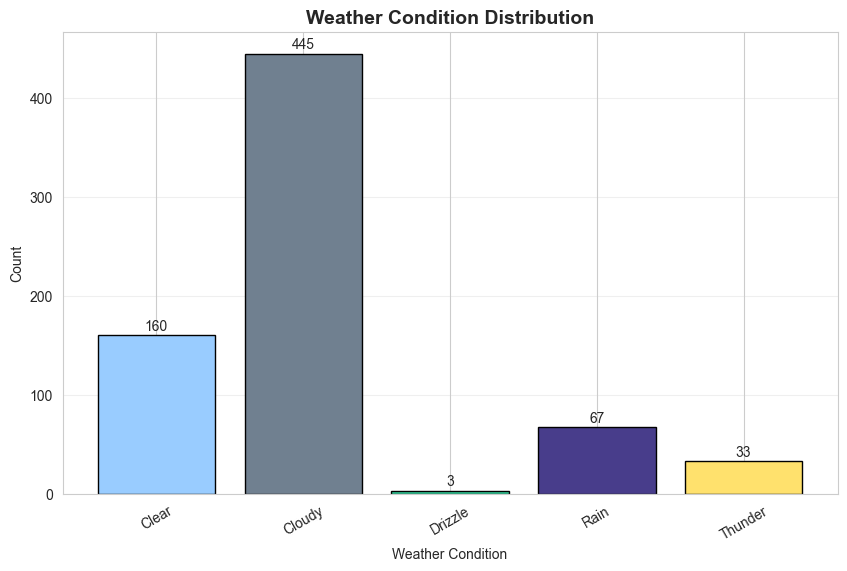

In [7]:
# Weather Con Distribution (Weather Classification)
cond_count = df['condition_text'].value_counts().sort_index()
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)

condition_map = mappings['condition_text']
cond_count.index = cond_count.index.map(lambda x: condition_map[str(x)])

plt.figure(figsize=(10,6))
bars = plt.bar(cond_count.index, cond_count.values,
               color=['#99CCFF','#708090','#33CC99','#483D8B','#ffe16d','#FF3399'],
               edgecolor='black')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5,
             f'{int(y):,}', ha='center', fontsize=10)

plt.title("Weather Condition Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.show()

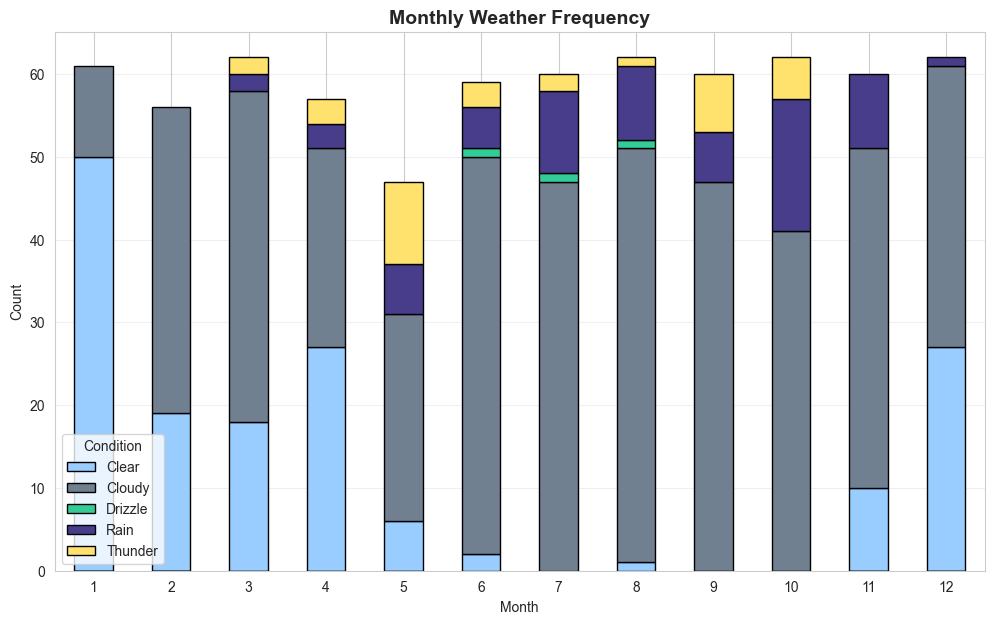

In [8]:
# Monthly Weather Freq (Weather Classification)
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)
condition_map = mappings['condition_text']

df['condition_name'] = df['condition_text'].map(lambda x: condition_map[str(x)])

monthly_weather = df.groupby(['month', 'condition_name']).size().unstack(fill_value=0)
monthly_weather.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#99CCFF','#708090','#33CC99','#483D8B','#ffe16d','#FF3399'],
    edgecolor='black'
)

plt.title("Monthly Weather Frequency", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.grid(axis='y', alpha=0.3)
plt.show()

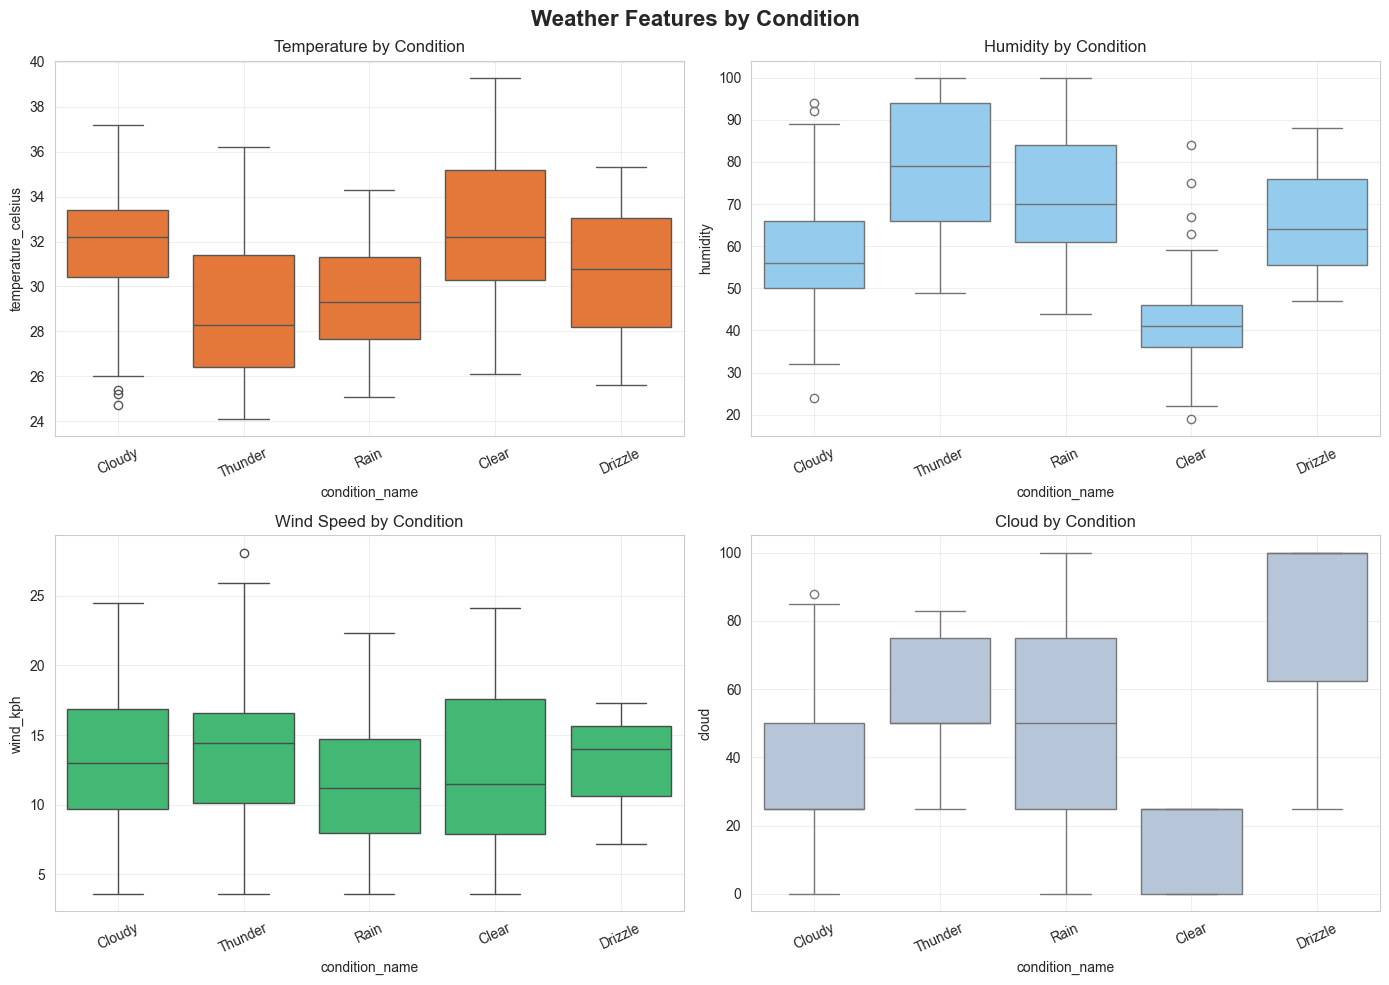

In [9]:
# Weather Features by Con (Weather Classification)
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)
condition_map = mappings['condition_text']

df['condition_name'] = df['condition_text'].map(lambda x: condition_map[str(x)])
plot_df = df[['condition_name', 'temperature_celsius', 'humidity', 'wind_kph', 'cloud']]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Weather Features by Condition", fontsize=16, fontweight='bold')

# Temp
sns.boxplot(data=plot_df, x='condition_name', y='temperature_celsius',
            ax=axes[0,0], color='#ff701e')
axes[0,0].set_title("Temperature by Condition")

# Humidity
sns.boxplot(data=plot_df, x='condition_name', y='humidity',
            ax=axes[0,1], color='#87CEFA')
axes[0,1].set_title("Humidity by Condition")

# Wind
sns.boxplot(data=plot_df, x='condition_name', y='wind_kph',
            ax=axes[1,0], color='#2ecc71')
axes[1,0].set_title("Wind Speed by Condition")

# Cloud
sns.boxplot(data=plot_df, x='condition_name', y='cloud',
            ax=axes[1,1], color='#B0C4DE')
axes[1,1].set_title("Cloud by Condition")

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

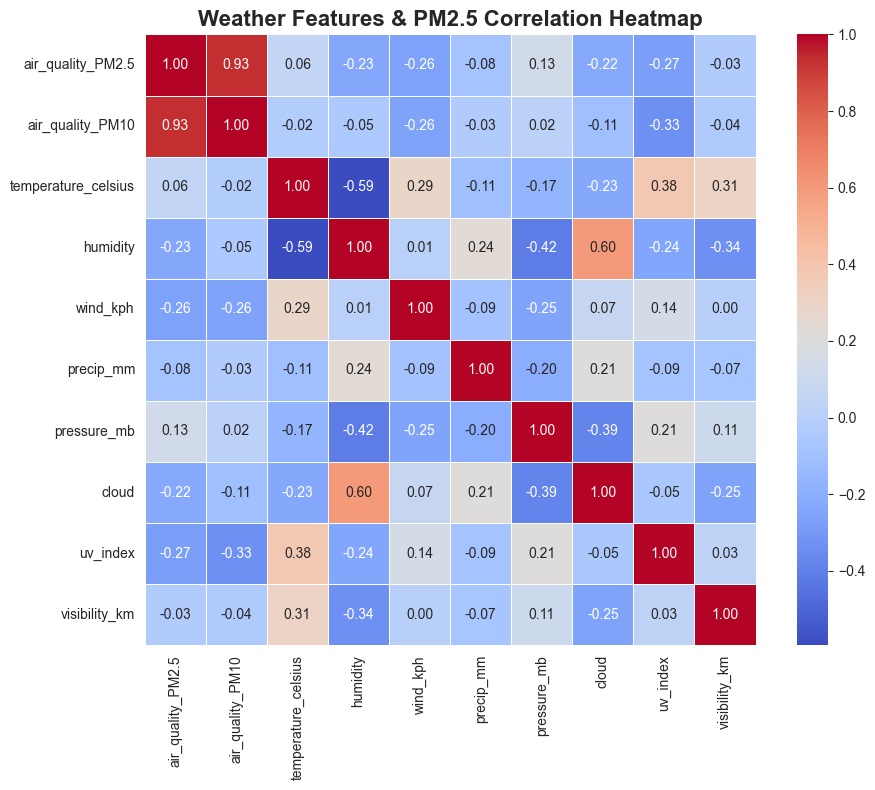

In [10]:
# Correlation Heatmap (PM2.5 Prediction)
cols = [
    'air_quality_PM2.5',
    'air_quality_PM10',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'pressure_mb',
    'cloud',
    'uv_index',
    'visibility_km',
]
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkokhm_df = bangkok_df[cols]
corr = bangkokhm_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Weather Features & PM2.5 Correlation Heatmap",fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

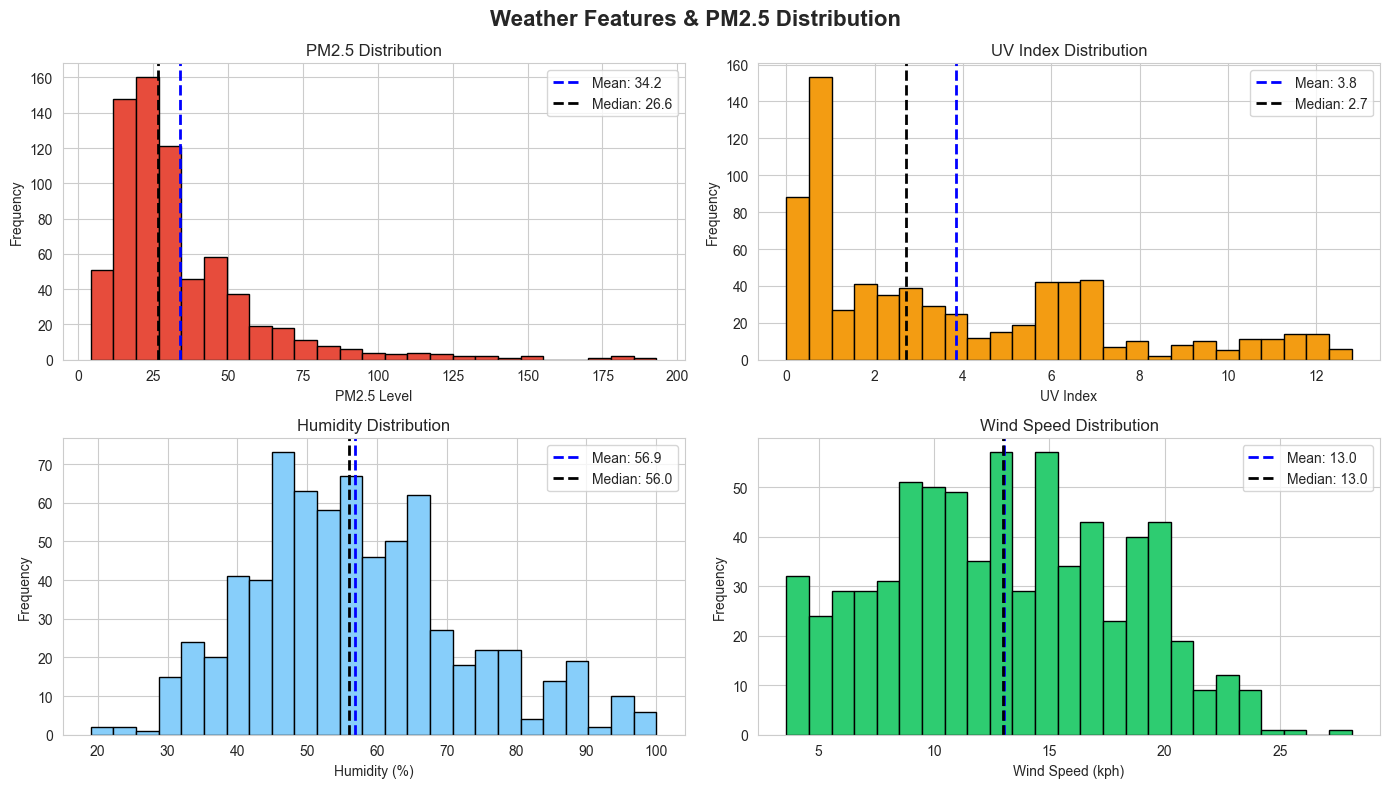

In [11]:
# Distribution (PM2.5 Prediction)
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Weather Features & PM2.5 Distribution", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'humidity', 'wind_kph']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

# PM2.5
mean_pm = bangkok_df['air_quality_PM2.5'].mean()
median_pm = bangkok_df['air_quality_PM2.5'].median()

axes[0,0].hist(bangkok_df['air_quality_PM2.5'], bins=25, color='#e74c3c', edgecolor='black')
axes[0,0].axvline(mean_pm, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_pm:.1f}')
axes[0,0].axvline(median_pm, color='black', linestyle='--', linewidth=2, label=f'Median: {median_pm:.1f}')
axes[0,0].set_title("PM2.5 Distribution")
axes[0,0].set_xlabel("PM2.5 Level")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# UV
mean_uv = bangkok_df['uv_index'].mean()
median_uv = bangkok_df['uv_index'].median()

axes[0,1].hist(bangkok_df['uv_index'], bins=25, color='#f39c12', edgecolor='black')
axes[0,1].axvline(mean_uv, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_uv:.1f}')
axes[0,1].axvline(median_uv, color='black', linestyle='--', linewidth=2, label=f'Median: {median_uv:.1f}')
axes[0,1].set_title("UV Index Distribution")
axes[0,1].set_xlabel("UV Index")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# Humidity
mean_h = bangkok_df['humidity'].mean()
median_h = bangkok_df['humidity'].median()

axes[1,0].hist(bangkok_df['humidity'], bins=25, color='#87CEFA', edgecolor='black')
axes[1,0].axvline(mean_h, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_h:.1f}')
axes[1,0].axvline(median_h, color='black', linestyle='--', linewidth=2, label=f'Median: {median_h:.1f}')
axes[1,0].set_title("Humidity Distribution")
axes[1,0].set_xlabel("Humidity (%)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend()

# Wind Speed
mean_w = bangkok_df['wind_kph'].mean()
median_w = bangkok_df['wind_kph'].median()

axes[1,1].hist(bangkok_df['wind_kph'], bins=25, color='#2ecc71', edgecolor='black')
axes[1,1].axvline(mean_w, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_w:.1f}')
axes[1,1].axvline(median_w, color='black', linestyle='--', linewidth=2, label=f'Median: {median_w:.1f}')
axes[1,1].set_title("Wind Speed Distribution")
axes[1,1].set_xlabel("Wind Speed (kph)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()

plt.tight_layout()
plt.show()

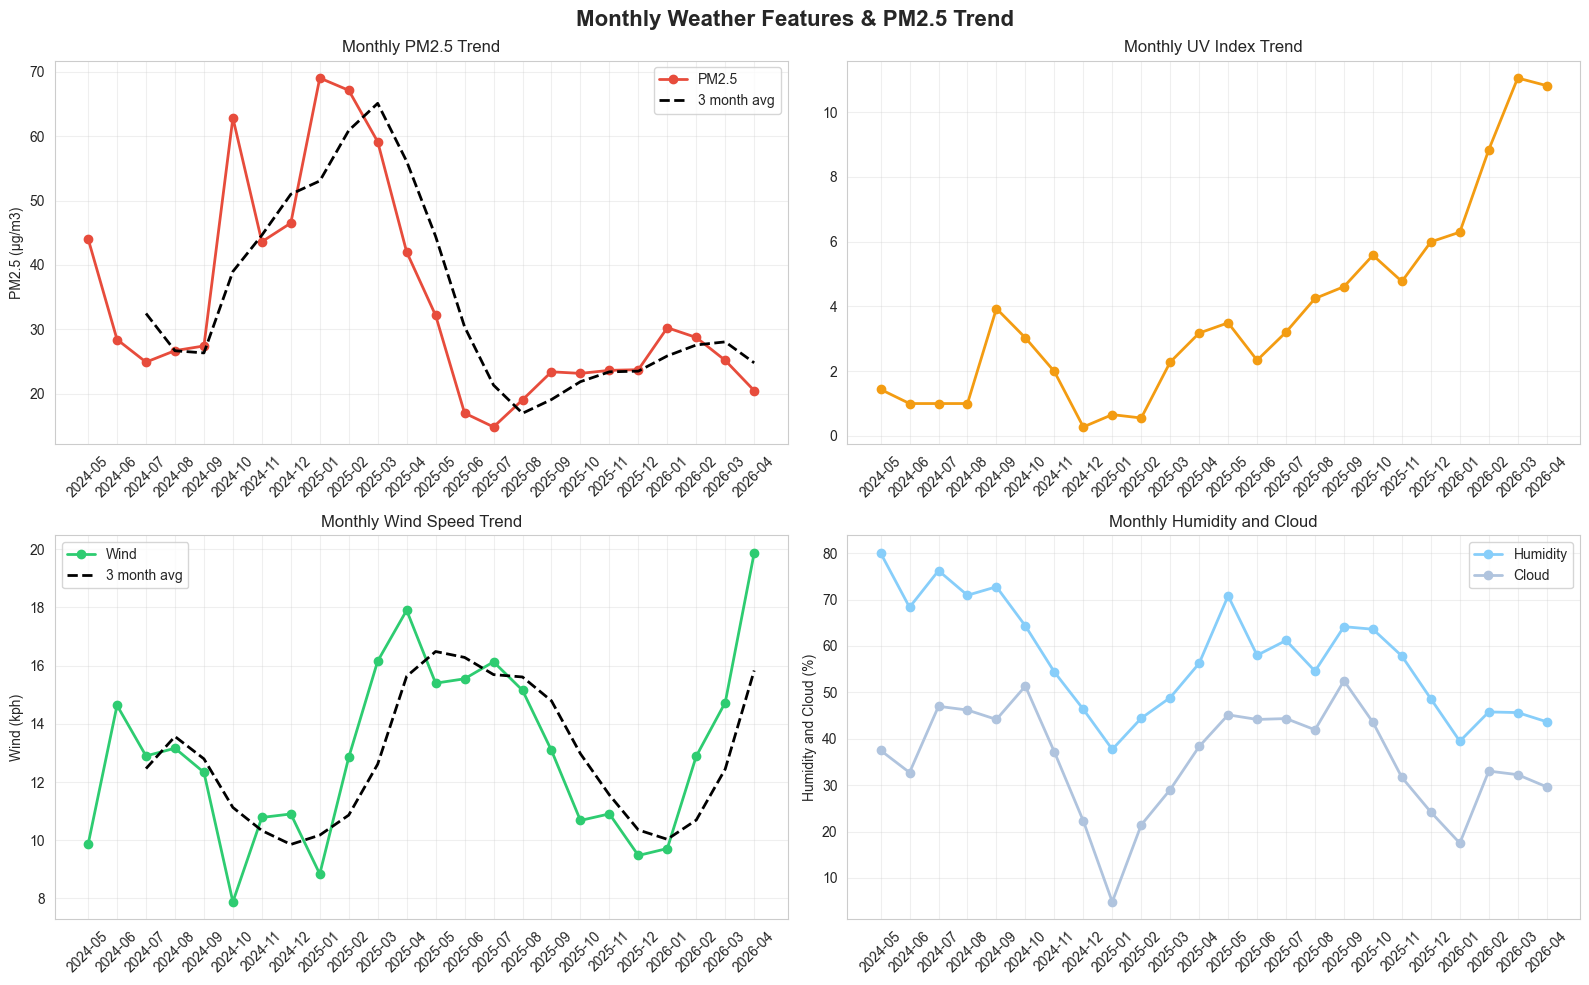

In [12]:
# Monthly Trend (PM2.5 Prediction)
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Monthly Weather Features & PM2.5 Trend", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'wind_kph', 'humidity', 'cloud']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df['year_month'] = (
    bangkok_df['year'].astype(int).astype(str) + '-' +
    bangkok_df['month'].astype(int).astype(str).str.zfill(2)
)
# monthly avg
monthly = bangkok_df.groupby('year_month')[cols].mean().reset_index()

# 3 month avg
monthly['pm_mavg3'] = monthly['air_quality_PM2.5'].rolling(3).mean()
monthly['wind_mavg3'] = monthly['wind_kph'].rolling(3).mean()

# PM2.5
axes[0,0].plot(monthly['year_month'], monthly['air_quality_PM2.5'],
               color='#e74c3c', marker='o', linewidth=2, label='PM2.5')
axes[0,0].plot(monthly['year_month'], monthly['pm_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[0,0].set_title("Monthly PM2.5 Trend")
axes[0,0].set_ylabel("PM2.5 (µg/m3)")
axes[0,0].legend()

# UV Index
axes[0,1].plot(monthly['year_month'], monthly['uv_index'],
               color='#f39c12', marker='o', linewidth=2)
axes[0,1].set_title("Monthly UV Index Trend")

# Wind
axes[1,0].plot(monthly['year_month'], monthly['wind_kph'],
               color='#2ecc71', marker='o', linewidth=2, label='Wind')
axes[1,0].plot(monthly['year_month'], monthly['wind_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[1,0].set_title("Monthly Wind Speed Trend")
axes[1,0].set_ylabel("Wind (kph)")
axes[1,0].legend()

# Humidity and Cloud
ax1 = axes[1,1]
ax2 = axes[1,1]

ax1.plot(monthly['year_month'], monthly['humidity'],
         color='#87CEFA', marker='o', linewidth=2, label='Humidity')

ax2.plot(monthly['year_month'], monthly['cloud'],
         color='#B0C4DE', marker='o', linewidth=2, label='Cloud')

ax1.set_title("Monthly Humidity and Cloud")
ax1.set_ylabel("Humidity and Cloud (%)")
ax1.legend()

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

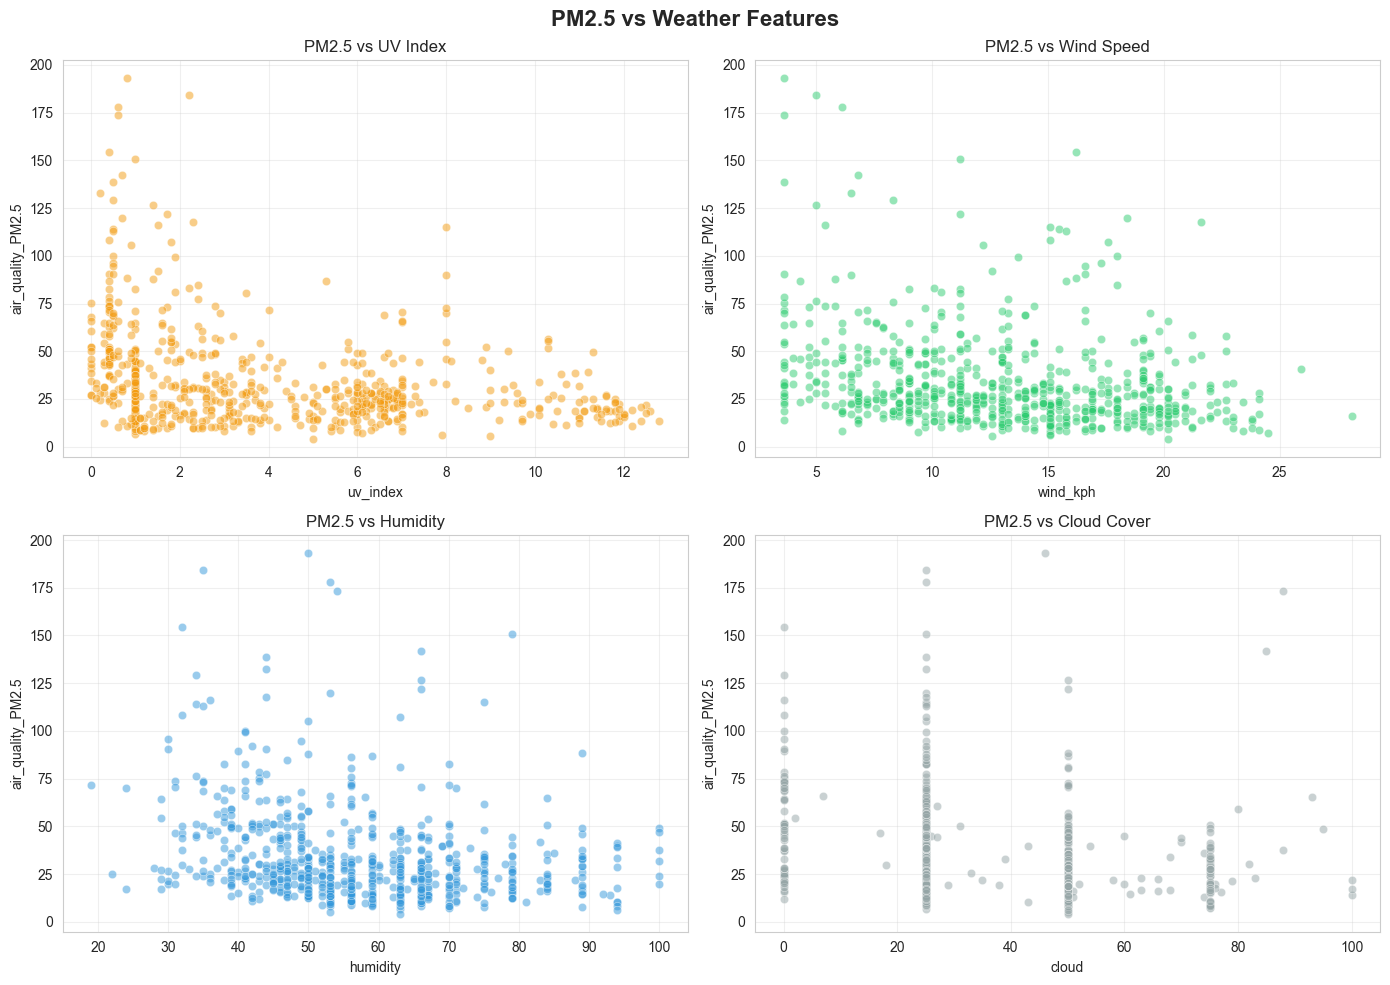

In [13]:
# PM2.5 Relationship (PM2.5 Prediction)
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("PM2.5 vs Weather Features", fontsize=16, fontweight='bold')

# PM2.5 vs UV
sns.scatterplot(data=df, x='uv_index', y='air_quality_PM2.5',
                ax=axes[0,0], color='#f39c12', alpha=0.5)
axes[0,0].set_title("PM2.5 vs UV Index")

# PM2.5 vs Wind
sns.scatterplot(data=df, x='wind_kph', y='air_quality_PM2.5',
                ax=axes[0,1], color='#2ecc71', alpha=0.5)
axes[0,1].set_title("PM2.5 vs Wind Speed")

# PM2.5 vs Humidity
sns.scatterplot(data=df, x='humidity', y='air_quality_PM2.5',
                ax=axes[1,0], color='#3498db', alpha=0.5)
axes[1,0].set_title("PM2.5 vs Humidity")

# PM2.5 vs Cloud
sns.scatterplot(data=df, x='cloud', y='air_quality_PM2.5',
                ax=axes[1,1], color='#95a5a6', alpha=0.5)
axes[1,1].set_title("PM2.5 vs Cloud Cover")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
#----------------------------
# Feature Engineering
#----------------------------

# Season from month
def get_season(month):
    if month in [11, 12, 1, 2]:
        return "Cool"
    elif month in [3, 4, 5]:
        return "Hot"
    else:
        return "Rainy"

bangkok_df['season'] = bangkok_df['month'].apply(get_season)

bangkok_df[['month', 'season']].sample(10)

,month,season
414,7,Rainy
616,1,Cool
567,12,Cool
548,11,Cool
94,8,Rainy
633,2,Cool
221,12,Cool
297,3,Hot
300,3,Hot
665,3,Hot


In [15]:
# Lag 1 day
bangkok_df['pm_lag'] = bangkok_df['air_quality_PM2.5'].shift(1)
bangkok_df['wind_lag'] = bangkok_df['wind_kph'].shift(1)
bangkok_df['uv_lag'] = bangkok_df['uv_index'].shift(1)
bangkok_df['humidity_lag'] = bangkok_df['humidity'].shift(1)
bangkok_df['cloud_lag'] = bangkok_df['cloud'].shift(1)

bangkok_df[['air_quality_PM2.5','pm_lag',
            'wind_kph','wind_lag',
            'uv_index','uv_lag',
            'humidity','humidity_lag',
            'cloud','cloud_lag']].head(10)

,air_quality_PM2.5,pm_lag,wind_kph,wind_lag,uv_index,uv_lag,humidity,humidity_lag,cloud,cloud_lag
0,115.2,NaN,15.1,NaN,8.0,NaN,75,NaN,25,NaN
1,150.8,115.2,11.2,15.1,1.0,8.0,79,75.0,25,25.0
2,33.2,150.8,9.0,11.2,1.0,1.0,75,79.0,25,25.0
3,14.8,33.2,9.0,9.0,1.0,1.0,89,75.0,50,25.0
4,65.0,14.8,6.1,9.0,1.0,1.0,84,89.0,25,50.0
5,25.9,65.0,3.6,6.1,1.0,1.0,89,84.0,25,25.0
6,26.1,25.9,9.0,3.6,1.0,1.0,75,89.0,50,25.0
7,28.5,26.1,6.8,9.0,1.0,1.0,94,75.0,50,50.0
8,31.7,28.5,13.0,6.8,1.0,1.0,75,94.0,25,50.0
9,18.3,31.7,6.1,13.0,1.0,1.0,79,75.0,25,25.0


In [16]:
# Interaction
bangkok_df['Humidity_over_Cloud'] = bangkok_df['humidity'] / bangkok_df['cloud']
bangkok_df['Humidity_over_Temp'] = bangkok_df['humidity'] / bangkok_df['temperature_celsius']
bangkok_df['Humidity_over_Visibility'] = bangkok_df['humidity'] / bangkok_df['visibility_km']
bangkok_df['Gust_over_Wind'] = bangkok_df['gust_kph'] / bangkok_df['wind_kph']
bangkok_df[[ 'temperature_celsius',
           'humidity',
           'visibility_km',
           'cloud',
           'gust_kph',
           'wind_kph',
           'Humidity_over_Cloud',
           'Humidity_over_Temp',
           'Humidity_over_Visibility',
           'Gust_over_Wind']].head(10)

,temperature_celsius,humidity,visibility_km,cloud,gust_kph,wind_kph,Humidity_over_Cloud,Humidity_over_Temp,Humidity_over_Visibility,Gust_over_Wind
0,31.0,75,10.0,25,18.2,15.1,3.00,2.419355,7.500000,1.205298
1,30.0,79,10.0,25,20.9,11.2,3.16,2.633333,7.900000,1.866071
2,31.0,75,10.0,25,24.1,9.0,3.00,2.419355,7.500000,2.677778
3,27.0,89,9.0,50,23.2,9.0,1.78,3.296296,9.888889,2.577778
4,30.0,84,10.0,25,24.8,6.1,3.36,2.800000,8.400000,4.065574
5,27.0,89,10.0,25,37.5,3.6,3.56,3.296296,8.900000,10.416667
6,30.0,75,10.0,50,17.0,9.0,1.50,2.500000,7.500000,1.888889
7,27.0,94,8.0,50,14.6,6.8,1.88,3.481481,11.750000,2.147059
8,30.0,75,10.0,25,20.2,13.0,3.00,2.500000,7.500000,1.553846
9,30.0,79,10.0,25,13.1,6.1,3.16,2.633333,7.900000,2.147541


In [17]:
# Day/Night
bangkok_df['is_day'] = bangkok_df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)
bangkok_df[['hour',
           'is_day']].sample(10)

,hour,is_day
302,16,1
661,13,1
337,16,1
69,19,0
204,18,1
320,16,1
16,21,0
301,16,1
387,16,1
267,17,1


In [18]:
#Weather Classification (condition_text)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RNG = 42

In [19]:
try:
    df_model = bangkok_df.copy()
    print("Loaded bangkok_df from memory (teammate's notebook)")
except NameError:
    print("bangkok_df not found — loading from Cleaned_Weather_Data.csv (standalone mode)")
    df_model = pd.read_csv("Cleaned_Weather_Data.csv")

    # สร้าง feature columns ที่เพื่อนทำไว้ขึ้นมาใหม่ เพื่อให้ชื่อตรงกัน
    def _season(m):
        if m in [11, 12, 1, 2]: return "Cool"
        if m in [3, 4, 5]:      return "Hot"
        return "Rainy"
    df_model["season"]   = df_model["month"].apply(_season)
    df_model["pm_lag"]       = df_model["air_quality_PM2.5"].shift(1)
    df_model["wind_lag"]     = df_model["wind_kph"].shift(1)
    df_model["uv_lag"]       = df_model["uv_index"].shift(1)
    df_model["humidity_lag"] = df_model["humidity"].shift(1)
    df_model["cloud_lag"]    = df_model["cloud"].shift(1)
    df_model["Humidity_over_Cloud"]      = df_model["humidity"] / df_model["cloud"]
    df_model["Humidity_over_Temp"]       = df_model["humidity"] / df_model["temperature_celsius"]
    df_model["Humidity_over_Visibility"] = df_model["humidity"] / df_model["visibility_km"]
    df_model["Gust_over_Wind"]           = df_model["gust_kph"] / df_model["wind_kph"]
    df_model["is_day"] = df_model["hour"].apply(lambda x: 1 if 6 <= x <= 18 else 0)

# แปลงเป็น datetime ให้ถูกต้อง + ลบแถวที่วันที่ซ้ำกันออก
df_model["date"] = pd.to_datetime(df_model[["year", "month", "day"]])
df_model = (df_model
            .sort_values("date")
            .drop_duplicates("date", keep="last")
            .reset_index(drop=True))

# อัตราส่วนที่เพื่อนสร้างไว้อาจได้ inf ถ้าตัวหารเป็น 0 ต้องจัดการด้วย
df_model = df_model.replace([np.inf, -np.inf], np.nan)
num_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

print(f"Rows: {len(df_model)}   |   Date range: {df_model['date'].min().date()} → {df_model['date'].max().date()}")
df_model[["date", "temperature_celsius", "humidity", "wind_kph", "precip_mm", "condition_text"]].tail()

Loaded bangkok_df from memory (teammate's notebook)
Rows: 707   |   Date range: 2024-05-16 → 2026-04-27


,date,temperature_celsius,humidity,wind_kph,precip_mm,condition_text
702,2026-04-23,36.2,53,23.4,0.00,Cloudy
703,2026-04-24,35.4,56,20.2,0.00,Cloudy
704,2026-04-25,33.1,59,18.7,0.01,Rain
705,2026-04-26,33.1,59,16.9,0.00,Cloudy
706,2026-04-27,37.4,42,19.8,0.00,Clear


In [20]:
LAG_COLS = ["temperature_celsius", "humidity", "wind_kph", "precip_mm",
            "pressure_mb", "cloud", "uv_index"]


def add_model_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["dayofyear"] = d["date"].dt.dayofyear
    d["doy_sin"]   = np.sin(2 * np.pi * d["dayofyear"] / 365.25)
    d["doy_cos"]   = np.cos(2 * np.pi * d["dayofyear"] / 365.25)
    for c in LAG_COLS:
        for lag in [1, 2, 3, 7]:
            d[f"{c}_lag{lag}"] = d[c].shift(lag)
        d[f"{c}_roll3"] = d[c].shift(1).rolling(3).mean()
        d[f"{c}_roll7"] = d[c].shift(1).rolling(7).mean()
    return d


feat = add_model_features(df_model)
print("After feature engineering:", feat.shape)

After feature engineering: (707, 83)


In [21]:
TEST_START = pd.Timestamp("2026-04-11")
TEST_END   = pd.Timestamp("2026-04-24")

lag_cols = [c for c in feat.columns if "_lag" in c or "_roll" in c]
data = feat.dropna(subset=lag_cols).reset_index(drop=True)

train = data[data["date"] <  TEST_START].copy()
test  = data[(data["date"] >= TEST_START) & (data["date"] <= TEST_END)].copy()
print(f"Train: {len(train)} rows   ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)} rows   ({test['date'].min().date()} → {test['date'].max().date()})")

# ตัด target ของ task อื่น (PM 2.5 regression) + คอลัมน์ที่จะเป็น leakage ออก
LEAK = {
    "date", "condition_text", "condition_name", "moon_phase",
    "air_quality_Carbon_Monoxide", "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5", "air_quality_PM10",
    "air_quality_us-epa-index", "air_quality_gb-defra-index",
    "moon_illumination",
    # อัตราส่วนของเพื่อนใช้ค่า ณ เวลา t เลย → leakage ต้องเอาออก
    "Humidity_over_Cloud", "Humidity_over_Temp",
    "Humidity_over_Visibility", "Gust_over_Wind",
}
FEATURES = [c for c in data.columns if c not in LEAK and data[c].dtype != "object"]
print(f"\n{len(FEATURES)} features used for classification.")

Train: 683 rows   (2024-05-24 → 2026-04-10)
Test : 14 rows   (2026-04-11 → 2026-04-24)

65 features used for classification.


In [22]:
le = LabelEncoder()
data["condition_y"]  = le.fit_transform(data["condition_text"])
train["condition_y"] = le.transform(train["condition_text"])
test["condition_y"]  = le.transform(test["condition_text"])

clf = RandomForestClassifier(n_estimators=400, random_state=RNG, n_jobs=-1,
                             class_weight="balanced")
clf.fit(train[FEATURES], train["condition_y"])

# ทดสอบกับข้อมูล 14 วัน (11–24 เม.ย.)
pred_test = clf.predict(test[FEATURES])
print("=== 14-day window (Apr 11–24) ===")
print(f"Accuracy: {accuracy_score(test['condition_y'], pred_test):.3f}")
print(f"Macro F1: {f1_score(test['condition_y'], pred_test, average='macro'):.3f}")

# ทดสอบย้อนหลัง 30 วัน เพื่อเช็กว่าโมเดลยังใช้ได้อยู่ (sanity check)
holdout = train.tail(30)
pred_30 = clf.predict(holdout[FEATURES])
print("\n=== 30-day backtest (sanity) ===")
print(f"Accuracy: {accuracy_score(holdout['condition_y'], pred_30):.3f}")
print(f"Macro F1: {f1_score(holdout['condition_y'], pred_30, average='macro'):.3f}")
print(classification_report(holdout['condition_y'], pred_30,
                            labels=list(range(len(le.classes_))),
                            target_names=le.classes_, zero_division=0))

=== 14-day window (Apr 11–24) ===
Accuracy: 0.929
Macro F1: 0.918

=== 30-day backtest (sanity) ===
Accuracy: 1.000
Macro F1: 1.000
              precision    recall  f1-score   support

       Clear       1.00      1.00      1.00        18
      Cloudy       1.00      1.00      1.00        10
     Drizzle       0.00      0.00      0.00         0
        Rain       0.00      0.00      0.00         0
     Thunder       1.00      1.00      1.00         2

    accuracy                           1.00        30
   macro avg       0.60      0.60      0.60        30
weighted avg       1.00      1.00      1.00        30



In [23]:
cmp = test[["date", "condition_text"]].copy()
cmp["condition_pred"]   = le.inverse_transform(pred_test)
cmp = cmp.rename(columns={"condition_text": "condition_actual"})
cmp["correct"] = cmp["condition_pred"] == cmp["condition_actual"]

cls_acc = cmp["correct"].mean()
n = len(cmp)
print(f"condition_text accuracy = {cls_acc:.2f}  ({int(round(cls_acc * n))}/{n} days)\n")
cmp

condition_text accuracy = 0.93  (13/14 days)



,date,condition_actual,condition_pred,correct
683,2026-04-11,Clear,Clear,True
684,2026-04-12,Clear,Clear,True
685,2026-04-13,Clear,Clear,True
686,2026-04-14,Clear,Clear,True
687,2026-04-15,Clear,Clear,True
688,2026-04-16,Clear,Clear,True
689,2026-04-17,Cloudy,Cloudy,True
690,2026-04-18,Clear,Clear,True
691,2026-04-19,Clear,Clear,True
692,2026-04-20,Clear,Clear,True


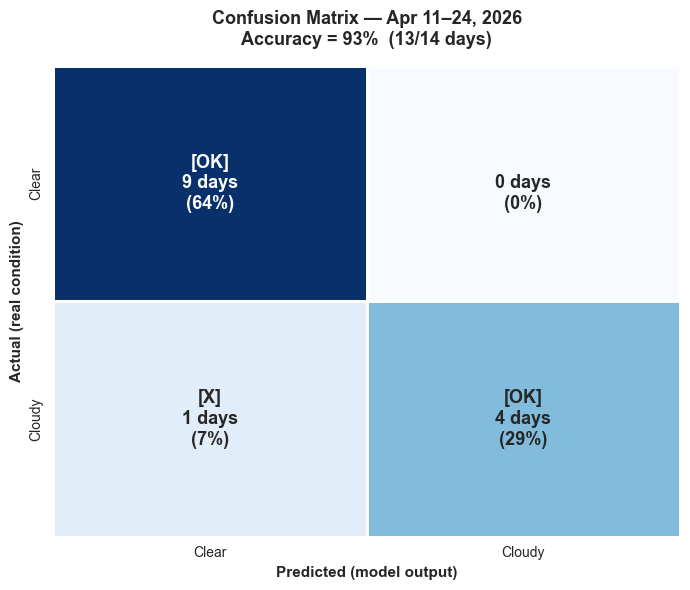

In [24]:
# Confusion Matrix — show count + percentage + check/cross marks
labels_present = np.unique(np.concatenate([test["condition_y"].values, pred_test]))
cm = confusion_matrix(test["condition_y"], pred_test, labels=labels_present)
label_names = le.inverse_transform(labels_present)
n_total = cm.sum()

# Build annotation : count + % + correct/wrong mark in each cell
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = count / n_total * 100
        if i == j:
            mark = "[OK]"
        elif count > 0:
            mark = "[X]"
        else:
            mark = ""
        annot[i, j] = f"{mark}\n{count} days\n({pct:.0f}%)"

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=False, linewidths=2, linecolor="white",
            annot_kws={"size": 13, "weight": "bold"}, ax=ax)

acc = np.trace(cm) / n_total
ax.set_title(f"Confusion Matrix — Apr 11–24, 2026\nAccuracy = {acc:.0%}  ({np.trace(cm)}/{n_total} days)",
             fontweight="bold", fontsize=13, pad=15)
ax.set_xlabel("Predicted (model output)", fontsize=11, fontweight="bold")
ax.set_ylabel("Actual (real condition)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

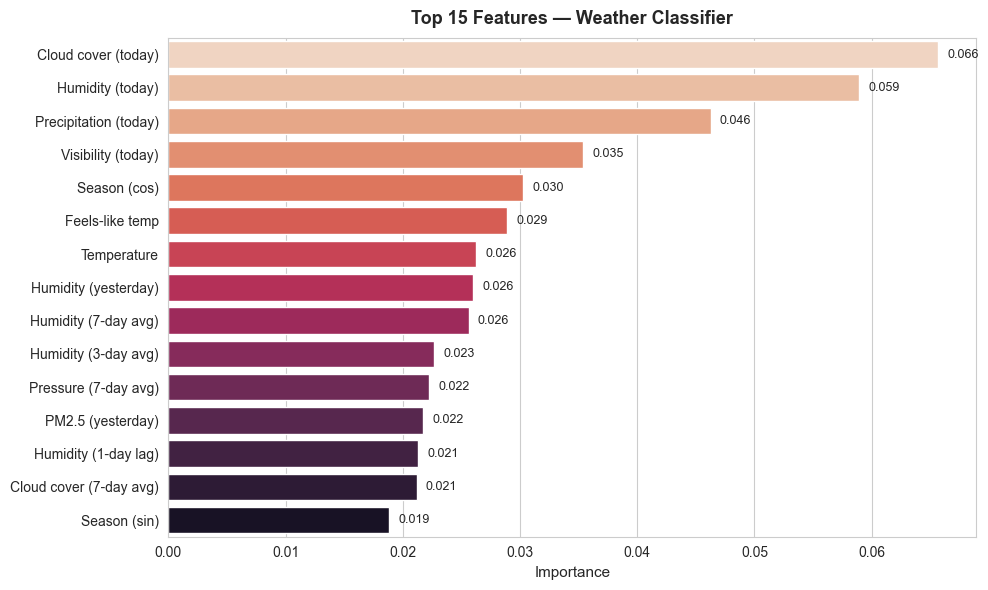

In [25]:
# Top features ของ classifier
FEATURE_NAMES_EN = {
    "cloud":              "Cloud cover (today)",
    "humidity":           "Humidity (today)",
    "precip_mm":          "Precipitation (today)",
    "visibility_km":      "Visibility (today)",
    "feels_like_celsius": "Feels-like temp",
    "temperature_celsius": "Temperature",
    "pressure_mb":        "Pressure",
    "uv_index":           "UV index",
    "wind_kph":           "Wind speed",
    "gust_kph":           "Wind gust",
    "doy_sin":            "Season (sin)",
    "doy_cos":            "Season (cos)",
    "dayofyear":          "Day of year",
    "month":              "Month",
    "hour":               "Hour",
    "is_day":             "Is daytime",
    "humidity_lag":       "Humidity (yesterday)",
    "cloud_lag":          "Cloud cover (yesterday)",
    "wind_lag":           "Wind speed (yesterday)",
    "uv_lag":             "UV (yesterday)",
    "pm_lag":             "PM2.5 (yesterday)",
}

def pretty_name(c: str) -> str:
    """Convert technical feature name to human-readable label."""
    if c in FEATURE_NAMES_EN:
        return FEATURE_NAMES_EN[c]
    # Handle auto-generated patterns: humidity_lag1, cloud_roll3, pressure_mb_lag7, ...
    for base, label in FEATURE_NAMES_EN.items():
        clean_label = label.split(" (")[0]  # drop suffix like " (today)"
        if c.startswith(base + "_lag"):
            n = c.replace(base + "_lag", "")
            return f"{clean_label} ({n}-day lag)"
        if c.startswith(base + "_roll"):
            n = c.replace(base + "_roll", "")
            return f"{clean_label} ({n}-day avg)"
    return c  # fallback

imp = pd.Series(clf.feature_importances_, index=FEATURES) \
        .sort_values(ascending=False).head(15)
imp_pretty = imp.copy()
imp_pretty.index = [pretty_name(c) for c in imp.index]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=imp_pretty.values, y=imp_pretty.index, palette="rocket_r")
for i, v in enumerate(imp_pretty.values):
    ax.text(v + 0.0008, i, f"{v:.3f}", va="center", fontsize=9)
plt.title("Top 15 Features — Weather Classifier",
          fontweight="bold", fontsize=13, pad=10)
plt.xlabel("Importance", fontsize=11)
plt.ylabel("")
plt.tight_layout(); plt.show()

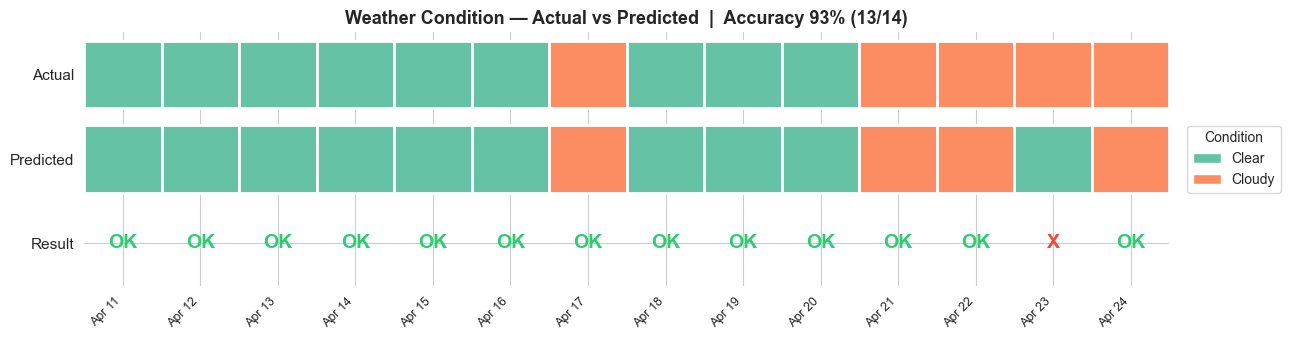

In [26]:
# Timeline แบบแถบสี
# มอง 3 แถว : Actual (จริง), Predicted (ทาย), Result (ถูก/ผิด)
from matplotlib.patches import Patch

all_classes = sorted(set(cmp['condition_actual']) | set(cmp['condition_pred']))
palette = dict(zip(all_classes, sns.color_palette('Set2', len(all_classes))))

fig, ax = plt.subplots(figsize=(13, 3.5))
n = len(cmp)

for i, row in cmp.reset_index(drop=True).iterrows():
    # Top row : Actual
    ax.barh(y=2, width=1, left=i, color=palette[row['condition_actual']],
            edgecolor='white', linewidth=2)
    # Middle row : Predicted
    ax.barh(y=1, width=1, left=i, color=palette[row['condition_pred']],
            edgecolor='white', linewidth=2)
    # Bottom row : correct / wrong  (use plain ASCII for matplotlib)
    correct = row['condition_actual'] == row['condition_pred']
    ax.text(i + 0.5, 0, 'OK' if correct else 'X',
            ha='center', va='center', fontsize=14,
            color='#2ecc71' if correct else '#e74c3c', fontweight='bold')

# Y-axis labels
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Result', 'Predicted', 'Actual'], fontsize=11)
ax.set_ylim(-0.5, 2.5)

# X-axis labels = dates
ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels([d.strftime('%b %d') for d in cmp['date']],
                   rotation=45, ha='right', fontsize=9)
ax.set_xlim(0, n)

# Color legend
legend_elems = [Patch(facecolor=palette[c], label=c) for c in all_classes]
ax.legend(handles=legend_elems, loc='center left',
          bbox_to_anchor=(1.01, 0.5), title='Condition')

acc = cmp['correct'].mean()
ax.set_title(f"Weather Condition — Actual vs Predicted  |  Accuracy {acc:.0%} ({cmp['correct'].sum()}/{n})",
             fontweight='bold', fontsize=13)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.tick_params(left=False, bottom=False)
plt.tight_layout(); plt.show()